# 04. Hard negatives, n-граммы и конкретные ошибки

Notebook читает predictions из `03_validation_split_audit.ipynb`; модели здесь
не обучаются. FPR/FNR — описательные показатели при фиксированном пороге 0.5.
Word n-граммы строятся для 1–3 слов, character n-граммы — для 3–5 символов.
Семантические комбинации анализируются отдельно.

In [1]:
import importlib.util
import subprocess
import sys

required_packages = {
    'rapidfuzz': 'rapidfuzz>=3.12,<4',
    'catboost': 'catboost==1.2.8',
    'sklearn': 'scikit-learn>=1.5,<2',
    'pyarrow': 'pyarrow>=17,<22',
    'matplotlib': 'matplotlib>=3.9,<4',
    'seaborn': 'seaborn>=0.13,<0.14',
    'tabulate': 'tabulate>=0.9,<1',
}
missing = [package for module, package in required_packages.items()
           if importlib.util.find_spec(module) is None]
if missing:
    print('Installing missing notebook dependencies:', missing)
    subprocess.run([sys.executable, '-m', 'pip', 'install', *missing], check=True)
    print('Dependencies installed. Restart the kernel once, then run all cells again.')
else:
    print('All notebook dependencies are available.')


All notebook dependencies are available.


In [2]:
from pathlib import Path
import json, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

ROOT = Path.cwd()
if not (ROOT / 'src').is_dir():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.validation_audit import (
    confusion_columns, hard_negative_table, pattern_error_rates,
    semantic_combination_rates, save_json,
)

INPUT_DIR = ROOT/'reports'/'validation_split_audit'
OUTPUT_DIR = ROOT/'reports'/'error_pattern_analysis'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
SPLIT_NAME = 'component_seed_42'  # после audit можно заменить на выбранный development split
THRESHOLD = 0.5
MIN_WORD_SUPPORT = 100
MIN_CHAR_SUPPORT = 200


## 1. Загружаем честные validation predictions

In [3]:
predictions = pd.read_parquet(INPUT_DIR/f'{SPLIT_NAME}_predictions.parquet')
predictions = confusion_columns(predictions, THRESHOLD)
print(predictions.error_type.value_counts())
category_error_rows = []
for category, part in predictions.groupby('category'):
    negative = part.target.eq(0); positive = part.target.eq(1)
    category_error_rows.append({
        'category': category, 'pairs': len(part), 'positive_rate': part.target.mean(),
        'fpr': part.loc[negative, 'is_fp'].mean() if negative.any() else np.nan,
        'fnr': part.loc[positive, 'is_fn'].mean() if positive.any() else np.nan,
    })
category_errors = pd.DataFrame(category_error_rows)
category_errors.to_csv(OUTPUT_DIR/'category_error_rates.csv', index=False)
display(category_errors)


error_type
correct    43139
FN          9160
FP          2588
Name: count, dtype: int64


,category,pairs,positive_rate,fpr,fnr
0,Автотовары,2859,0.179084,0.012356,0.812500
1,Аптека,2692,0.078009,0.006446,0.833333
2,Бытовая техника,2682,0.361298,0.157034,0.586171
3,Бытовая химия,2571,0.476857,0.312268,0.429853
4,Галантерея и аксессуары,2649,0.167610,0.009524,0.939189
5,Детские товары,2683,0.569512,0.525541,0.229058
6,Дом и сад,2632,0.249240,0.024798,0.772866
7,Канцелярские товары,2570,0.333463,0.071804,0.768961
8,Красота и гигиена,2635,0.357875,0.104019,0.696713
9,Мебель,2806,0.142908,0.006237,0.915212


## 2. Hard negatives

In [4]:
hard = hard_negative_table(predictions)
hard.to_parquet(OUTPUT_DIR/'hard_negatives.parquet', index=False)
display(hard[['id1','id2','category','name_1','name_2','predict','hard_score','critical_conflict']].head(100))


,id1,id2,category,name_1,name_2,predict,hard_score,critical_conflict
34246,532576076146,188978623089,Бытовая техника,electrolux вентилятор argentum eafa-120t с та...,вентилятор вытяжной electrolux argentum eafa-1...,0.494521,0.867347,False
5000,77309447873,360777402303,Автотовары,диск тормозной зад brembo 09d53113,тормозной диск brembo комплект 2 шт. 09d53113,0.546528,0.855208,True
33156,515396172215,309237720443,Спорт и отдых,беговая дорожка cardiopower s500,cardiopower беговая дорожка s500,0.803027,0.850000,False
9454,146028985462,816043824088,Бытовая техника,водонагреватель накопительный zanussi zwh/s 80...,zanussi водонагреватель накопительный zwh/s 80...,0.792299,0.841509,True
12483,197568506367,618475390812,Бытовая техника,ariston водонагреватель накопительный водонагр...,водонагреватель накопительный ariston abs blu1...,0.746595,0.834746,True
...,...,...,...,...,...,...,...,...
28889,446676747294,515396093137,Детские товары,мягкая игрушка maxitoys мишка обаяшка с сердце...,мягкая игрушка maxitoys мишка белый с сердцем ...,0.480909,0.771875,False
25254,395137053574,824633846105,Мебель,двухъярусная кровать легенда cc603-606 белый 1...,двухъярусная кровать легенда cc603-606 сонома/...,0.241885,0.771875,True
35569,558345793752,523986095287,Электроника,стекло защитное гибридное матовое krutoff для ...,стекло защитное гибридное krutoff для камеры i...,0.471158,0.771429,False
49635,773094196430,68719499606,Музыкальные инструменты,цифровое пианино roland f701-la,пианино цифровое roland f701-wh,0.260776,0.770968,False


## 3. Общие словесные и символьные n-граммы с частыми ошибками

In [5]:
word_patterns = pattern_error_rates(predictions, kind='word', min_support=MIN_WORD_SUPPORT)
char_patterns = pattern_error_rates(predictions, kind='char', min_support=MIN_CHAR_SUPPORT)
word_patterns.to_csv(OUTPUT_DIR/'word_ngram_error_rates.csv', index=False)
char_patterns.to_csv(OUTPUT_DIR/'char_ngram_error_rates.csv', index=False)
display(word_patterns.sort_values(['fpr','negative_support'], ascending=False).head(80))
display(word_patterns.sort_values(['fnr','positive_support'], ascending=False).head(80))


,kind,pattern,support,negative_support,positive_support,positive_rate,fpr,fnr,false_positives,false_negatives
113,word,настольная игра,114,9,105,0.921053,0.777778,0.142857,7,15
111,word,игра,246,38,208,0.845528,0.684211,0.153846,26,32
537,word,кукла,108,46,62,0.574074,0.652174,0.209677,30,13
302,word,набор для,203,85,118,0.581281,0.600000,0.203390,51,24
5,word,мягкая игрушка,334,161,173,0.517964,0.534161,0.213873,86,37
...,...,...,...,...,...,...,...,...,...,...
194,word,для волос,178,100,78,0.438202,0.170000,0.653846,17,51
83,word,250,443,260,183,0.413093,0.169231,0.491803,44,90
188,word,цвета,116,77,39,0.336207,0.168831,0.358974,13,14
14,word,35,192,114,78,0.406250,0.166667,0.474359,19,37


,kind,pattern,support,negative_support,positive_support,positive_rate,fpr,fnr,false_positives,false_negatives
236,word,585,946,868,78,0.082452,0.000000,1.000000,0,78
133,word,диванов,370,313,57,0.154054,0.003195,1.000000,1,57
132,word,лига диванов,368,312,56,0.152174,0.000000,1.000000,0,56
383,word,бюстгальтер,229,176,53,0.231441,0.000000,1.000000,0,53
146,word,sokolov,488,436,52,0.106557,0.000000,1.000000,0,52
...,...,...,...,...,...,...,...,...,...,...
131,word,лига,385,327,58,0.150649,0.000000,0.982759,0,57
134,word,диван,668,582,86,0.128743,0.001718,0.976744,1,84
145,word,кольцо,1620,1376,244,0.150617,0.002180,0.975410,3,238
437,word,костюм,156,123,33,0.211538,0.008130,0.969697,1,32


## 4. Семантические комбинации: brand + color, model + number conflict и другие

,combination,support,positive_rate,negative_support,positive_support,fpr,fnr,mean_prediction
20,brand_conflict + measure_match,1693,0.360307,1083,610,0.109880,0.570492,0.340990
7,measure_match,16546,0.339840,10923,5623,0.096311,0.610528,0.324792
14,brand_match + measure_match,1399,0.290922,992,407,0.095766,0.560197,0.320996
40,measure_match + measure_conflict,13143,0.316975,8977,4166,0.087446,0.641623,0.306200
23,model_match + color_conflict,68,0.602941,27,41,0.074074,0.682927,0.324340
26,model_match + measure_conflict,86,0.651163,30,56,0.066667,0.821429,0.275437
8,measure_conflict,21828,0.257055,16217,5611,0.063267,0.677419,0.265659
21,brand_conflict + measure_conflict,2006,0.242273,1520,486,0.058553,0.668724,0.256841
36,color_conflict + measure_match,3071,0.149137,2613,458,0.057405,0.746725,0.239555
15,brand_match + measure_conflict,1506,0.211155,1188,318,0.057239,0.694969,0.253537


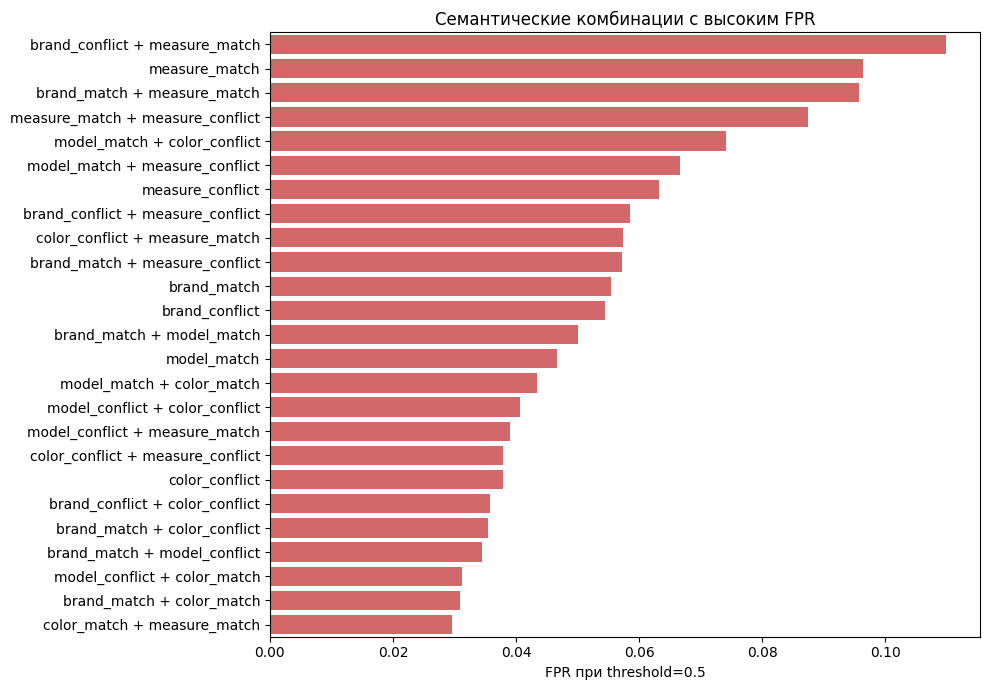

In [6]:
combinations = semantic_combination_rates(predictions, min_support=50)
combinations.to_csv(OUTPUT_DIR/'semantic_combination_error_rates.csv', index=False)
display(combinations.head(100))
plot_data = combinations.dropna(subset=['fpr']).sort_values(['fpr','support'], ascending=False).head(25)
if len(plot_data):
    figure, axis = plt.subplots(figsize=(10, 7))
    sns.barplot(data=plot_data, x='fpr', y='combination', ax=axis, color='#E45756')
    axis.set(title='Семантические комбинации с высоким FPR', xlabel='FPR при threshold=0.5', ylabel='')
    figure.tight_layout(); figure.savefig(OUTPUT_DIR/'semantic_combination_fpr.png', dpi=160, bbox_inches='tight')
    plt.show()


## 5. Конкретные FP/FN для ручной проверки

In [7]:
false_positives = predictions[predictions.is_fp].sort_values('predict', ascending=False)
false_negatives = predictions[predictions.is_fn].sort_values('predict', ascending=True)
columns = [
    'id1','id2','category','name_1','name_2','target','predict',
    'name_token_set_ratio','name_numeric_jaccard','number_conflict',
    'measure_match','measure_conflict','brand_match','brand_conflict',
    'model_match','model_conflict','color_match','color_conflict',
]
false_positives[columns].head(1000).to_csv(OUTPUT_DIR/'top_false_positives.csv', index=False)
false_negatives[columns].head(1000).to_csv(OUTPUT_DIR/'top_false_negatives.csv', index=False)
display(false_positives[columns].head(50))
display(false_negatives[columns].head(50))


,id1,id2,category,name_1,name_2,target,predict,name_token_set_ratio,name_numeric_jaccard,number_conflict,measure_match,measure_conflict,brand_match,brand_conflict,model_match,model_conflict,color_match,color_conflict
486,140635,283467967999,Детские товары,"no name мягкая игрушка «авокадо», заяц, 25 см","мягкая игрушка авокадо, заяц, 25 см",0.0,0.962416,0.875000,1.000000,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
10828,171798703016,128102,Бытовая техника,швейная машина janome 1547,janome швейная машина 1547,0.0,0.958150,1.000000,1.000000,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
23974,377957138674,25674,Детские товары,"танк радиоуправляемый fighter, 4wd, управление...","noname танк радиоуправляемый fighter, 4wd, упр...",0.0,0.953499,1.000000,1.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
49673,773094208205,824633805538,Детские товары,"набор детской посуды ""микки"" 2 предмета: салат...","disney набор детской посуды ""микки"" 2 предмета...",0.0,0.953292,1.000000,1.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
54885,850403683771,231928288442,Детские товары,"грузовик радиоуправляемый самосвал, работает о...","грузовик радиоуправляемый «самосвал», работает...",0.0,0.951269,0.982759,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
47877,747324369616,515396152463,Хобби и творчество,без бренда набор для творчества «новогодний па...,набор для творчества новогодний пазл-аппликация,0.0,0.948739,0.878505,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6910,103079301415,77309532713,Детские товары,uni-fortune / машинка металлическая uni-fortun...,машинка металлическая uni-fortune rmz city 1:3...,0.0,0.947273,0.983607,1.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
39332,609885504467,850403552404,Бытовая техника,тепловентилятор керамический электрический equ...,тепловентилятор керамический электрический equ...,0.0,0.943765,1.000000,1.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1551,17179989050,163208847527,Бытовая химия,"glade освежитель воздуха цитрусовый, 300 мл","освежитель воздуха glade ""цитрусовый"", 300 мл",0.0,0.940370,0.977273,1.000000,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
496,142672,584115671889,Детские товары,sluban / конструктор космические войны осада к...,"конструктор космические войны осада крепости, ...",0.0,0.940050,1.000000,1.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


,id1,id2,category,name_1,name_2,target,predict,name_token_set_ratio,name_numeric_jaccard,number_conflict,measure_match,measure_conflict,brand_match,brand_conflict,model_match,model_conflict,color_match,color_conflict
30051,472446408617,566935808036,Аптека,очки с футляром-змейка melorsch мод. 2110 цвет...,очки с футляром-змейка melorsch мод. 2110 цвет...,1.0,0.001776,0.954545,0.500000,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
45474,704374789407,77309546794,Аптека,"no name готовые очки женские с диоптриями, очк...",восток готовые очки 0056 розовые -4.0,1.0,0.007637,0.489796,0.000000,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
39178,609885465752,687194920354,Одежда,топ ava,размер 95f,1.0,0.007759,0.117647,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
31317,489626340631,120259148686,Аптека,без бренда для работы готовые очки с uv защито...,женские готовые очки -5.50 с uv защитой очки ...,1.0,0.008319,0.770833,0.000000,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
14043,214748499921,472446450406,Аптека,растер дезинфицирующее средство «део-хлор» сан...,"дезинфицирующее средство растер ""део-хлор сани...",1.0,0.010294,0.817610,0.166667,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
33513,523986075712,661425090352,Аптека,контактные линзы acuvue oasys 1-day with hydra...,acuvue oasys 1-day with hydraluxe for astigmat...,1.0,0.011753,0.683417,0.200000,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25300,395137063860,584115679690,Галантерея и аксессуары,часы наручные наручные,casio / часы наручные,1.0,0.012804,1.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
24226,377957217392,841813656560,Галантерея и аксессуары,playtoday бандана,бандана playtoday,1.0,0.013513,1.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
18792,292057915606,670014995856,Аптека,ликопид 1 мг 10 шт. таблетки,"ликопид 0,001 n10 таблетки",1.0,0.015074,0.777778,0.333333,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
52015,807453991904,498216351201,Одежда,ветровка rm shopping,ruf mark / куртка льняная,1.0,0.015262,0.266667,0.000000,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


## 6. Черновик отчёта

In [8]:
top_combo = combinations.iloc[0] if len(combinations) else None
lines = ['# Результаты анализа ошибок', '', f'- Split: `{SPLIT_NAME}`.', f'- Порог FPR/FNR: `{THRESHOLD}`.',
         f'- FP: `{int(predictions.is_fp.sum())}`, FN: `{int(predictions.is_fn.sum())}`.',
         f'- Hard negatives сохранены: `{len(hard)}` строк.', '']
if top_combo is not None:
    lines.append(f"- Наибольший наблюдаемый FPR среди поддержанных комбинаций: `{top_combo.combination}` = `{top_combo.fpr:.3f}` при support `{int(top_combo.support)}`.")
lines += ['', 'Полные таблицы: `word_ngram_error_rates.csv`, `char_ngram_error_rates.csv`, `semantic_combination_error_rates.csv`, `top_false_positives.csv`, `top_false_negatives.csv`.']
(OUTPUT_DIR/'report.md').write_text('\n'.join(lines), encoding='utf-8')
save_json(OUTPUT_DIR/'manifest.json', {'status':'complete','split':SPLIT_NAME,'threshold':THRESHOLD})
(OUTPUT_DIR/'COMPLETED').write_text('ok\n', encoding='utf-8')
print(OUTPUT_DIR/'report.md')


C:\Users\Professional\product_matching\reports\error_pattern_analysis\report.md
